### **Filtracja sygnału - przykład**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [4]:
# Parametry próbkowania
fs = 1000  # Częstotliwość próbkowania [Hz]
t = np.arange(0, 1.0, 1/fs)  # Czas: 1 sekunda

In [6]:
# Sygnał użyteczny (np. 5 Hz) + Szum (np. 50 Hz i 120 Hz)
clean_signal = np.sin(2 * np.pi * 5 * t)
noise = 0.5 * np.sin(2 * np.pi * 50 * t) + 0.3 * np.sin(2 * np.pi * 120 * t)
noisy_signal = clean_signal + noise

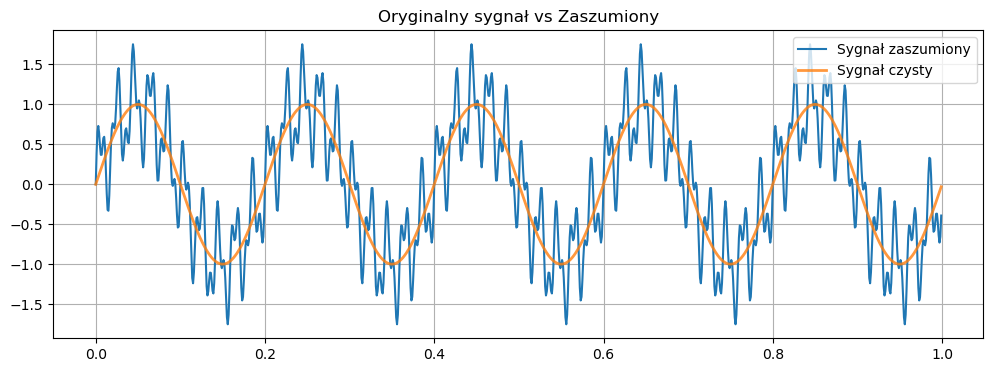

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(t, noisy_signal, label='Sygnał zaszumiony')
plt.plot(t, clean_signal, label='Sygnał czysty', alpha=0.8, lw=2)
plt.legend()
plt.title("Oryginalny sygnał vs Zaszumiony")
plt.grid(True)

### **Projektowanie filtra dolnoprzepustowego (Low-pass)
Chcemy odciąć wszystko powyżej 15 Hz, aby pozbyć się szumu. Wykorzystamy funkcję signal.butter.Ważne pojęcie: Częstotliwość Nyquista ($f_{Nyquist} = \frac{f_s}{2}$). W scipy, parametry filtra podajemy w skali znormalizowanej względem tej wartości.

In [11]:
# Parametry filtra
cutoff = 15.0  # Częstotliwość odcięcia [Hz]
order = 4      # Rząd filtra (im wyższy, tym ostrzejsze odcięcie)

In [13]:
# Normalizacja częstotliwości (0 do 1, gdzie 1 to Nyquist)
nyq = 0.5 * fs
normal_cutoff = cutoff / nyq

In [15]:
# Generowanie współczynników filtra (b - licznik, a - mianownik)
b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)

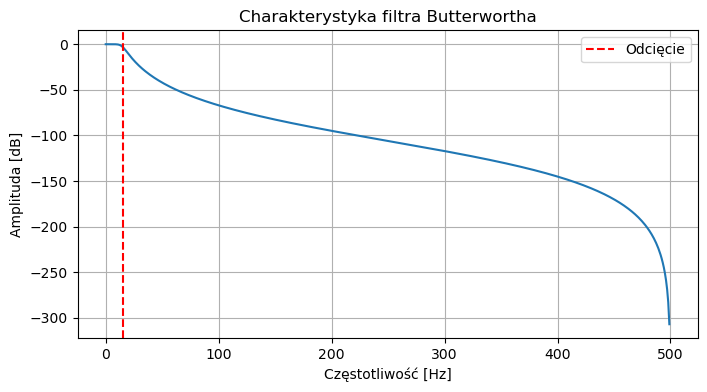

In [17]:
# Charakterystyka częstotliwościowa
w, h = signal.freqz(b, a, fs=fs)
plt.figure(figsize=(8, 4))
plt.plot(w, 20 * np.log10(abs(h)))
plt.axvline(cutoff, color='red', linestyle='--', label='Odcięcie')
plt.title("Charakterystyka filtra Butterwortha")
plt.ylabel("Amplituda [dB]")
plt.xlabel("Częstotliwość [Hz]")
plt.grid(True)
plt.legend()

### **Aplikacja filtra**
- lfilter: Filtracja przyczynowa (wprowadza przesunięcie fazowe/opóźnienie).
- filtfilt: Filtracja dwustronna (zerowe przesunięcie fazowe) – idealna do analizy danych historycznych w medycynie.

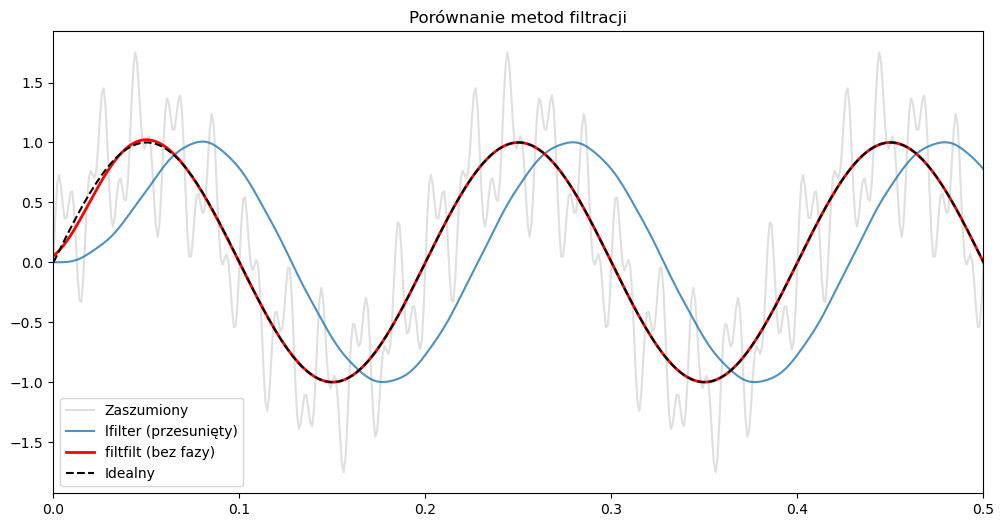

In [20]:
# Aplikacja filtra
filtered_lfilter = signal.lfilter(b, a, noisy_signal)
filtered_filtfilt = signal.filtfilt(b, a, noisy_signal)

plt.figure(figsize=(12, 6))
plt.plot(t, noisy_signal, color='silver', label='Zaszumiony', alpha=0.5)
plt.plot(t, filtered_lfilter, label='lfilter (przesunięty)', alpha=0.8)
plt.plot(t, filtered_filtfilt, 'r', label='filtfilt (bez fazy)', lw=2)
plt.plot(t, clean_signal, 'k--', label='Idealny')
plt.xlim(0, 0.5) # Powiększenie fragmentu
plt.legend()
plt.title("Porównanie metod filtracji")
plt.show()